In [1]:
import pandas as pd
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_recall_curve, accuracy_score
from sklearn.discriminant_analysis import StandardScaler

import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV

In [2]:
import talib  # библиотека для расчёта индикаторов

In [3]:
import warnings
warnings.filterwarnings('ignore')

## Грузим датасеты

In [4]:
# 1. Загрузка данных
# Предполагаем, что есть CSV с колонками: datetime, open, high, low, close, volume
# df = pd.read_csv('dowload_data/CNYRUBF_1Min.txt', parse_dates=['datetime'], index_col='datetime')
def readQuotes(path):
    try:
        quotes = pd.read_csv(path, sep=';')
        quotes['date'] = quotes['date'] + ' ' + quotes['time']
        del quotes['time']
        quotes['date'] = pd.to_datetime(quotes['date'], format='%d.%m.%Y %H:%M:%S', errors='raise', dayfirst=True)
        quotes.index = quotes['date']
        quotes.index.name = 'Date'
        del quotes['date']
        quotes[quotes.columns].astype(float)
        return quotes
    except pd.errors.EmptyDataError:
        print(f"File {path} is empty")
        return pd.DataFrame()
    except pd.errors.ParserError as e:
        print(f"Error parsing file {path}: {e}")

In [63]:
df_base = readQuotes('..\dowload_data\CNYRUBF_5Min.txt')
df_base.tail()

,open,high,low,close,volume
Date,,,,,
2025-05-12 23:25:00,11.146,11.146,11.145,11.145,635
2025-05-12 23:30:00,11.145,11.145,11.134,11.137,2461
2025-05-12 23:35:00,11.137,11.145,11.137,11.145,268
2025-05-12 23:40:00,11.141,11.148,11.139,11.142,463
2025-05-12 23:45:00,11.147,11.149,11.133,11.138,1613


In [5]:
df_history = readQuotes('..\dowload_data\CNYRUBF_15Min_history.txt')
df_history.tail()

,open,high,low,close,volume
Date,,,,,
2025-05-12 22:45:00,11.146,11.148,11.145,11.145,641
2025-05-12 23:00:00,11.146,11.149,11.145,11.146,3216
2025-05-12 23:15:00,11.148,11.149,11.145,11.145,1915
2025-05-12 23:30:00,11.145,11.148,11.134,11.142,3192
2025-05-12 23:45:00,11.147,11.149,11.133,11.138,1613


In [ ]:
df_base = pd.concat([df_history, df_base])

In [7]:
# 2. Параметры стратегии
N = 20 #48    # число баров во входном окне (6*5 мин = 30 мин признаков)
M = 6  #12   # число баров вперед для оценки результата (т.е. через 30 мин)

50% квантиль абсолютных движений: 0.0290
70% квантиль абсолютных движений: 0.0460
80% квантиль абсолютных движений: 0.0590
90% квантиль абсолютных движений: 0.0830
95% квантиль абсолютных движений: 0.1120
99% квантиль абсолютных движений: 0.1980


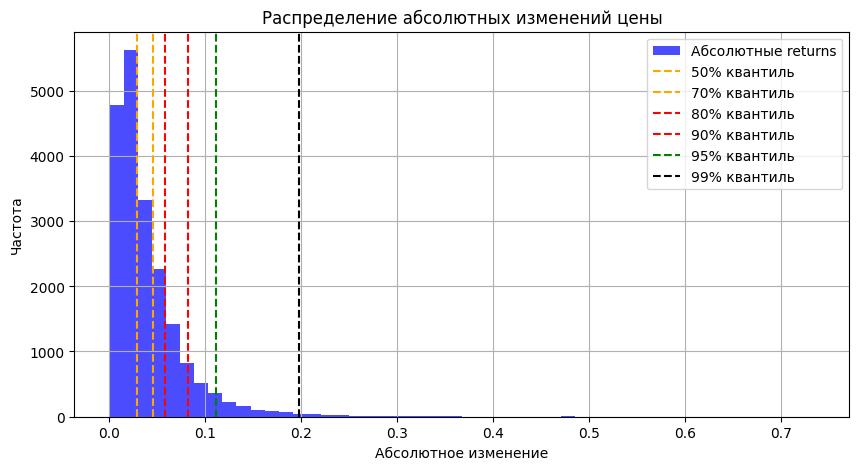

In [8]:
# 1. Считаем логарифмические returns (можно и простые: .pct_change())

roll_max = df_base['high'].rolling(M).max() - df_base['close'].rolling(M+1).apply(lambda x: x[0])
roll_min = df_base['close'].rolling(M+1).apply(lambda x: x[0]) - df_base['low'].rolling(M).min()

max_up_move = roll_max #(roll_max - current_price)# / current_price
max_down_move = roll_min #(current_price - roll_min)# / current_price
returns = np.maximum(max_up_move, max_down_move).dropna()
abs_returns = np.abs(returns)  # Абсолютные значения

# 2. Вычисляем квантили (например, 90%, 95%, 99%)
threshold_50 = abs_returns.quantile(0.50)
threshold_70 = abs_returns.quantile(0.70)
threshold_80 = abs_returns.quantile(0.80)
threshold_90 = abs_returns.quantile(0.90)
threshold_95 = abs_returns.quantile(0.95)
threshold_99 = abs_returns.quantile(0.99)

print(f"50% квантиль абсолютных движений: {threshold_50:.4f}")
print(f"70% квантиль абсолютных движений: {threshold_70:.4f}")
print(f"80% квантиль абсолютных движений: {threshold_80:.4f}")
print(f"90% квантиль абсолютных движений: {threshold_90:.4f}")
print(f"95% квантиль абсолютных движений: {threshold_95:.4f}")
print(f"99% квантиль абсолютных движений: {threshold_99:.4f}")

# Визуализация распределения
plt.figure(figsize=(10, 5))
plt.hist(abs_returns, bins=50, alpha=0.7, color='blue', label='Абсолютные returns')
plt.axvline(threshold_50, color='orange', linestyle='--', label='50% квантиль')
plt.axvline(threshold_70, color='orange', linestyle='--', label='70% квантиль')
plt.axvline(threshold_80, color='red', linestyle='--', label='80% квантиль')
plt.axvline(threshold_90, color='red', linestyle='--', label='90% квантиль')
plt.axvline(threshold_95, color='green', linestyle='--', label='95% квантиль')
plt.axvline(threshold_99, color='black', linestyle='--', label='99% квантиль')
plt.title('Распределение абсолютных изменений цены')
plt.xlabel('Абсолютное изменение')
plt.ylabel('Частота')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# df_base['h-l'] = (df_base['high'].shift(1) - df_base['low'].shift(1)) / (df_base['high'] - df_base['low'])
# df_base['o-c'] = (df_base['open'].shift(1) - df_base['close'].shift(1)) / (df_base['open'] - df_base['close'])
# df_base['v-chng'] = 1 - (df_base['volume'].shift(1) / df_base['volume'])
df_base['h-chng'] = 1 - (df_base['high'].shift(1) / df_base['high'])
df_base['l-chng'] = 1 - (df_base['low'].shift(1) / df_base['low'])
df_base['c-chng'] = 1 - (df_base['close'].shift(1) / df_base['close'])
df_base['o-chng'] = 1 - (df_base['open'].shift(1) / df_base['open'])

df_base['RSI'] = talib.RSI(df_base['close'], timeperiod=14)
# df_base['rsi-chng'] = df_base['RSI'].shift(1) / df_base['RSI']

# df_base['SAR'] = talib.SAR(df_base['high'], df_base['low'])
# df_base['sar-chng'] = 1 - (df_base['SAR'].shift(1) / df_base['SAR'])
# df_base['sar-close-chng'] = 1 - ((df_base['SAR'].shift(1) - df_base['close'].shift(1)) / (df_base['SAR']-df_base['close']))

macd, macd_signal, macd_hist = talib.MACD(df_base['close'], fastperiod=12, slowperiod=26, signalperiod=9)
df_base['MACD'] = macd_hist
# df_base['MACDM'] = macd
# df_base['MACDSIG'] = macd_signal

# df_base['ATR'] = talib.ATR(df_base['high'], df_base['low'], df_base['close'], timeperiod=14)
# df_base['atr-chng'] = 1 - df_base['ATR'].shift(1) / df_base['ATR']

# df_base['EMA'] = talib.EMA(df_base['close'], timeperiod=14)
# df_base['ema-chng'] = 1 - (df_base['EMA'].shift(1) / df_base['EMA'])

# up_b, mid_b, low_b = talib.BBANDS(df_base['close'], timeperiod=14, nbdevup=2, nbdevdn=2)
# df_base['up-bb'] = up_b
# df_base['mid-bb'] = mid_b
# df_base['low-bb'] = low_b
# df_base['LINREG'] = talib.LINEARREG(df_base['close'], timeperiod=14)
# df_base['cl-EMA'] = df_base['close'] - df_base['EMA']

# df_base['EMA-ATR'] = df_base['EMA'] / df_base['ATR']
# df_base['MACD-slope'] = df_base['MACD'].diff()

## Генерация фичей

In [10]:
# 3. Генерация признаков
# Собираем колонку для каждого смещения: o_{-i}, h_{-i}, l_{-i}, c_{-i}, v_{-i}
df = df_base.loc[:'2025-04-29 10:00:00',:].copy()
for i in range(1, N):
    # df[f'o_{i}'] = df['open'].shift(i)
    # df[f'h_{i}'] = df['high'].shift(i)
    # df[f'l_{i}'] = df['low'].shift(i)
    # df[f'c_{i}'] = df['close'].shift(i)
    # df[f'v_{i}'] = df['volume'].shift(i)

    # df[f'rsi_{i}'] = df['RSI'].shift(i)
    df[f'macd_{i}'] = df['MACD'].shift(i)
    # df[f'macdm_{i}'] = df['MACD'].shift(i)
    # df[f'macdsig_{i}'] = df['MACD'].shift(i)
    # df[f'atr_{i}'] = df['ATR'].shift(i)
    # df[f'ema_{i}'] = df['EMA'].shift(i)
    # df[f'up-bb_{i}'] = df['up-bb'].shift(i)
    # df[f'mid-bb_{i}'] = df['mid-bb'].shift(i)
    # df[f'low-bb_{i}'] = df['low-bb'].shift(i)
    # df[f'linreg_{i}'] = df['LINREG'].shift(i)

    # df[f'cl-ema_{i}'] = df['cl-EMA'].shift(i)

    # df[f'h-l_{i}'] = df['h-l'].shift(i)
    # df[f'o-c_{i}'] = df['o-c'].shift(i)
    
    # CHANGING

    df[f'c-chng_{i}'] = df['c-chng'].shift(i)
    df[f'o-chng_{i}'] = df['o-chng'].shift(i)
    df[f'h-chng_{i}'] = df['h-chng'].shift(i)
    df[f'l-chng_{i}'] = df['l-chng'].shift(i)
    # df[f'v-chng_{i}'] = df['v-chng'].shift(i)
    # df[f'rsi-chng_{i}'] = df['rsi-chng'].shift(i)
    # df[f'atr-chng_{i}'] = df['atr-chng'].shift(i)
    # df[f'ema-chng_{i}'] = df['ema-chng'].shift(i)
    # df[f'sar-chng_{i}'] = df['sar-chng'].shift(i)
    # df[f'sar-close-chng_{i}'] = df['sar-close-chng'].shift(i)
    
    df[f'rsi_{i}'] = df['RSI'].shift(i)

# 4. Целевая метка: направление движения через M баров
s_max = []
s_min = []
for i in range(len(df)):
    s_max.append(round(df.iloc[i+1:i+M+1]['high'].max() - df.iloc[i]['close'], 3))
    s_min.append(round(df.iloc[i+1:i+M+1]['low'].min() - df.iloc[i]['close'], 3))

df['future-ret-up'] = s_max
df['future-ret-down'] = s_min

threshold = 0.059
# df['y'] = np.where(df['future-ret-up'] > threshold, 1,
#                    np.where(df['future-ret-down'] < -threshold, -1, 0))


# Оставим только метки 1 и -1 (убираем flat)
# df = df[df['y'] != 0]

df['y'] = np.where(df['future-ret-up'] > threshold, 1,
                   np.where(df['future-ret-down'] < -threshold, 0, -1))

# Оставим только метки 1 и -1 (убираем flat)
# df = df[df['y'] != -1]

# 5. Формируем X и y, убираем NaN
feature_cols = [col for col in df.columns if '_' in col]  # все o_i, h_i, ..., v_i
X = df[feature_cols].dropna()
y = df.loc[X.index, 'y']

In [111]:
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X = X[feature_cols].dropna()
y = y.loc[X.index]

### Распределение меток

<Axes: xlabel='y'>

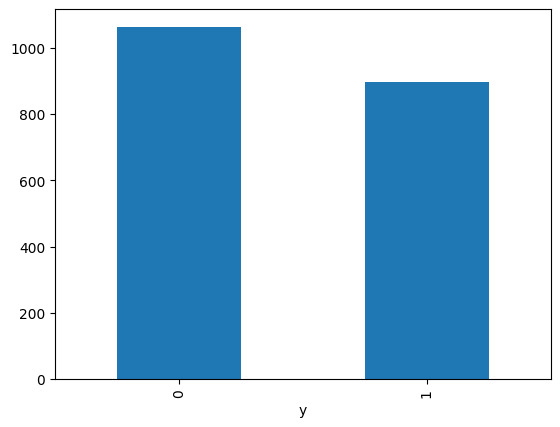

In [169]:
y.value_counts().plot(kind='bar')

## Подбор важных фич

<Axes: >

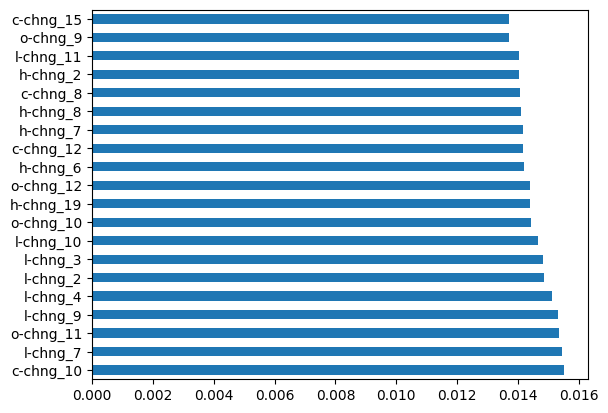

In [170]:
pipeline = make_pipeline(
    StandardScaler(),  # Нормализация
    RandomForestClassifier(random_state=42)  # Модель
)
pipeline.fit(X, y)
model = pipeline.steps[1][1]

# model = RandomForestClassifier()
# # X_ = X.between_time('10:00', '19:00')
# # y_ = y.loc[X_.index]
# model.fit(X, y)  # X — ваши данные, y — метки

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(20).plot(kind='barh')

<Axes: >

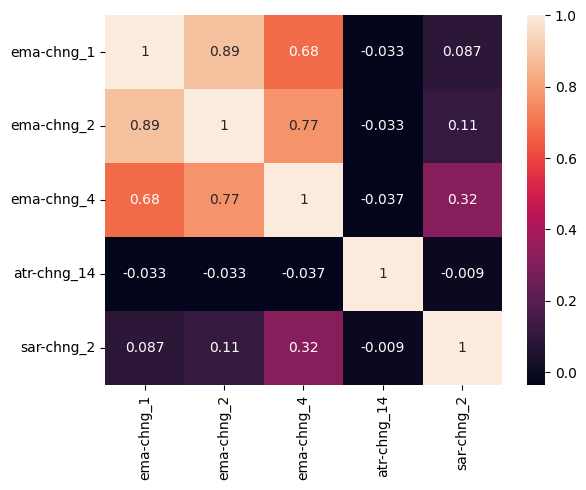

In [74]:
import seaborn as sns

sns.heatmap(X[importances.nlargest(5).index].corr(), annot=True)

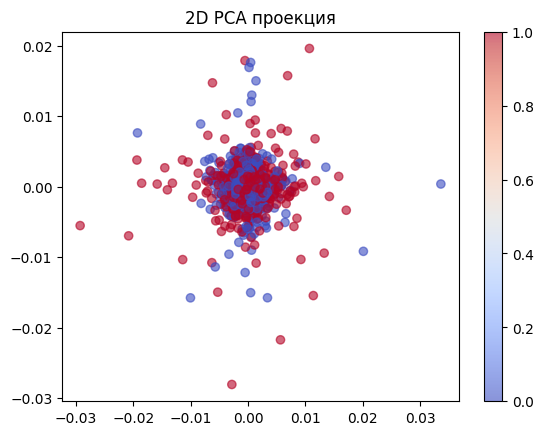

In [171]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# X = X_
# y = y_
X_ = X[importances.nlargest(7).index]

pca = PCA(n_components=3)  # для 3D
X_reduced = pca.fit_transform(X_)

# 2D график
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap='coolwarm', alpha=0.6)
plt.colorbar()
plt.title("2D PCA проекция")
plt.show()

In [172]:
import plotly.express as px

df3d = pd.DataFrame(
    X_reduced, 
    columns=['PC1', 'PC2', 'PC3']
)
df3d['Target'] = y.values
fig = px.scatter_3d(
    df3d,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Target',
    symbol='Target',
)
fig.update_layout(margin=dict(l=0, r=0, b=0, t=30))
fig.show()

# # 3D график
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# scatter = ax.scatter(X_reduced[:, 0], X_reduced[:, 1], X_reduced[:, 2], c=y, cmap='coolwarm')
# plt.colorbar(scatter)
# plt.title("3D PCA проекция")
# plt.show()

In [176]:
from sklearn.metrics import silhouette_score

# Коэффициент силуэта (Silhouette Score)
# Для исходных данных (X) и меток (y)
score = silhouette_score(X[importances.nlargest(3).index], y)
print(f"Silhouette Score: {score:.5f}")
if score > 0.5:
    print('Хорошая разделимость')
elif score < 0:
    print('Объекты ошибочно кластеризованы')
else:
    print('Классы пересекаются')

Silhouette Score: 0.03058
Классы пересекаются


In [177]:
from sklearn.metrics import davies_bouldin_score

# Индекс Дэвиса-Болдуина (Davies-Bouldin Index)
# Davies-Bouldin ≈ 0 → хорошая разделимость.
db_score = davies_bouldin_score(X[importances.nlargest(3).index], y)
print(f"Davies-Bouldin Index: {db_score:.3f}")

Davies-Bouldin Index: 54.642


### Разбиение на train, test

In [178]:
# 6. Разбиение на train/test
X_ = X[importances.nlargest(3).index]
X_train, X_test, y_train, y_test = train_test_split(
    X_, y, test_size=0.3, random_state=42, stratify=y
)
# X_ = X[importances.nlargest(3).index]
# tscv = TimeSeriesSplit(n_splits=5)
# for train_index, test_index in tscv.split(X_):
#     X_train, X_test = X_.iloc[train_index], X_.iloc[test_index]
#     y_train, y_test = y.iloc[train_index], y.iloc[test_index]

In [154]:
print(
    y_test.index.min(),
    y_test.index.max()
)

2024-01-08 12:00:00 2025-04-23 09:45:00


### Ridge

In [179]:
from sklearn.linear_model import RidgeClassifier

# Параметры для GridSearchCV
param_grid = {
    'alpha': [0.1, 1.0, 10.0, 100.0],  # основной параметр RidgeClassifier
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
    'tol': [1e-3, 1e-4, 1e-5],
    'class_weight': [None, 'balanced']
}

# pipeline = make_pipeline(
#     #StandardScaler(),  # Нормализация
#     RidgeClassifier()  # Модель
# )
pipeline = RidgeClassifier()

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,  # количество фолдов кросс-валидации
    scoring='f1',  # или другой показатель (f1, precision, recall, roc_auc)
    n_jobs=-1,  # использовать все ядра CPU
    verbose=2
)


grid_search.fit(X_train, y_train)
model_ridge = grid_search.best_estimator_

# 8. Оценка качества
y_pred = model_ridge.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
print("F1-score:", f1_score(y_test, y_pred))
confusion_matrix(y_test, y_pred)
# model_ridge

Fitting 5 folds for each of 168 candidates, totalling 840 fits
              precision    recall  f1-score   support

           0     0.5432    0.4734    0.5059       319
           1     0.4581    0.5279    0.4905       269

    accuracy                         0.4983       588
   macro avg     0.5006    0.5006    0.4982       588
weighted avg     0.5042    0.4983    0.4988       588

F1-score: 0.4905008635578584


array([[151, 168],
       [127, 142]], dtype=int64)

### Logistic

In [ ]:
from sklearn.linear_model import LogisticRegression

param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet'],  # тип регуляризации
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],  # сила регуляризации
    'solver': ['liblinear', 'saga'],  # только эти solver'ы работают с L1
    'max_iter': [100, 200, 500],
    'class_weight': [None, 'balanced']
}

# pipeline = make_pipeline(
#     #StandardScaler(),  # Нормализация
#     LogisticRegression()
# )
pipeline = LogisticRegression()

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,  # 5-fold кросс-валидация
    scoring='f1',  # 'accuracy' или 'f1', 'roc_auc' и т.д.
    n_jobs=-1,  # использовать все ядра CPU
    verbose=2  # вывод логов
)

grid_search.fit(X_train, y_train)
model_log = grid_search.best_estimator_

# 8. Оценка качества
y_pred = model_log.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
print("F1-score:", f1_score(y_test, y_pred))

# # Кросс-валидация и оценка производительности
cv_scores = cross_val_score(model_log, X_train, y_train, cv=5, scoring='f1')
average_score = cv_scores.mean()
print("Cross-Validation Scores:", cv_scores)
print("Average Score:", average_score)

confusion_matrix(y_test, y_pred)
# model_log

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
              precision    recall  f1-score   support

           0     0.5434    1.0000    0.7042       319
           1     1.0000    0.0037    0.0074       269

    accuracy                         0.5442       588
   macro avg     0.7717    0.5019    0.3558       588
weighted avg     0.7523    0.5442    0.3854       588

F1-score: 0.007407407407407408
Cross-Validation Scores: [0.03100775 0.03100775 0.         0.01587302 0.        ]
Average Score: 0.015577703949796972


array([[319,   0],
       [268,   1]], dtype=int64)

In [182]:
print(X_.columns)
print(model_log.coef_)
print(model_log.intercept_)

Index(['c-chng_10', 'l-chng_7', 'o-chng_11'], dtype='object')
[[ 1.50816418 -1.20293918 13.60618212]]
[-0.17179406]


### Baess

In [158]:
from sklearn.naive_bayes import GaussianNB

pipeline = make_pipeline(
    #StandardScaler(),  # Нормализация
    GaussianNB()
)
pipeline.fit(X_train, y_train)
model_gauss = pipeline

# 8. Оценка качества
y_pred = model_gauss.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
print("F1-score:", f1_score(y_test, y_pred))
confusion_matrix(y_test, y_pred)

# # Кросс-валидация и оценка производительности
cv_scores = cross_val_score(model_gauss, X_train, y_train, cv=5, scoring='f1')
average_score = cv_scores.mean()
print("Cross-Validation Scores:", cv_scores)
print("Average Score:", average_score)
confusion_matrix(y_test, y_pred)
# model_gauss

              precision    recall  f1-score   support

           0     0.5526    0.3950    0.4607       319
           1     0.4639    0.6208    0.5310       269

    accuracy                         0.4983       588
   macro avg     0.5083    0.5079    0.4958       588
weighted avg     0.5120    0.4983    0.4929       588

F1-score: 0.5310015898251192
Cross-Validation Scores: [0.08450704 0.27807487 0.61035422 0.35406699 0.59598854]
Average Score: 0.3845983312649611


array([[126, 193],
       [102, 167]], dtype=int64)

### SVC

In [159]:
from sklearn.svm import SVC


param_grid = {
    'C': [0.1, 1, 10, 100],  # сила регуляризации (меньше C → больше регуляризация)
    'kernel': ['linear'],  # тип ядра
    'gamma': ['scale', 'auto'] + [0.001, 0.01, 0.1],  # коэффициент ядра (для rbf, poly, sigmoid)
    # 'degree': [2, 3, 4],  # степень полинома (только для kernel='poly')
    # 'coef0': [0.0, 0.1, 0.5],  # свободный член в ядре (для poly и sigmoid)
    'class_weight': [None, 'balanced'],  # балансировка классов
    # 'shrinking': [True, False],  # использовать ли эвристику "shrinking"
    # 'probability': [True, False],  # вычислять ли вероятности (нужно для predict_proba)
    'tol': [1e-3, 1e-4],  # допуск сходимости
    'max_iter': [1000, 2000, 5000]  # ограничение итераций (если не сходится)
}
# pipeline = make_pipeline(
#     #StandardScaler(),  # Нормализация
#     SVC(kernel='linear')
# )
pipeline = SVC()

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,  # 5-fold кросс-валидация
    scoring='f1',  # 'accuracy' или 'f1', 'roc_auc' и т.д.
    n_jobs=-1,  # использовать все ядра CPU
    verbose=2  # вывод логов
)

grid_search.fit(X_train, y_train)
model_svc = grid_search.best_estimator_

# 8. Оценка качества
y_pred = model_svc.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
print("F1-score:", f1_score(y_test, y_pred))
confusion_matrix(y_test, y_pred)
# model_svc

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
              precision    recall  f1-score   support

           0     0.4828    0.0439    0.0805       319
           1     0.4544    0.9442    0.6135       269

    accuracy                         0.4558       588
   macro avg     0.4686    0.4941    0.3470       588
weighted avg     0.4698    0.4558    0.3243       588

F1-score: 0.6135265700483091


array([[ 14, 305],
       [ 15, 254]], dtype=int64)

In [201]:
model_svc.steps[0][1].__dict__

{'with_mean': True,
 'with_std': True,
 'copy': True,
 'feature_names_in_': array(['rsi_0', 'atr_0', 'atr_19'], dtype=object),
 'n_features_in_': 3,
 'n_samples_seen_': 4479,
 'mean_': array([4.95441225e+01, 1.95450690e-02, 1.68386800e-02]),
 'var_': array([2.00154966e+02, 1.59468178e-04, 1.37700103e-04]),
 'scale_': array([1.41476134e+01, 1.26280710e-02, 1.17345687e-02])}

### RandomForest

In [98]:
# Предположим, что X_train, y_train уже определены
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 7, None],
    'min_samples_leaf': [1, 2, 5, 7 , 10],
    'criterion': ['gini', 'entropy']
}

rf = RandomForestClassifier(random_state=42)
# Создаём пайплайн с нормализацией и моделью
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',  # или 'roc_auc', 'f1' и т.д.
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучшее CV-качество:", grid_search.best_score_)

# Используйте лучшую модель для предсказаний:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
print("F1-score:", f1_score(y_test, y_pred))
confusion_matrix(y_test, y_pred)
# best_model

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Лучшие параметры: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 100}
Лучшее CV-качество: 0.558200701275348
              precision    recall  f1-score   support

           0     0.5760    0.5186    0.5458       862
           1     0.5373    0.5943    0.5644       811

    accuracy                         0.5553      1673
   macro avg     0.5567    0.5564    0.5551      1673
weighted avg     0.5573    0.5553    0.5548      1673

F1-score: 0.5644028103044496


array([[447, 415],
       [329, 482]], dtype=int64)

In [99]:
from sklearn.inspection import permutation_importance

result = permutation_importance(best_model, X_test, y_test, n_repeats=10)
sorted_idx = result.importances_mean.argsort()

In [164]:
sorted_idx

array([2, 0, 1, 3, 8, 7, 6, 4, 5], dtype=int64)

In [996]:
# # Кросс-валидация и оценка производительности
# cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy')
# average_score = cv_scores.mean()

# print("Cross-Validation Scores:", cv_scores)
# print("Average Score:", average_score)

In [ ]:
# 9. Функция предсказания вероятностей для новых данных
def predict_signal(recent_bars: pd.DataFrame, model) -> pd.Series:
    """
    recent_bars: DataFrame из последних N баров с колонками ['open','high','low','close','volume'].
    Должен быть упорядочен по времени, индекс не обязателен.
    """
    # Проверка размера
    assert len(recent_bars) >= N, f"Нужно минимум {N} баров, передано {len(recent_bars)}"
    # Берем последние N строк
    window = recent_bars.iloc[-N:].copy()
    feats = {}
    for i in range(N):
        row = window.iloc[-1-i]
        print(row)
        feats.update({
            f'o_{i}': row['open'],
            f'h_{i}': row['high'],
            f'l_{i}': row['low'],
            f'c_{i}': row['close'],
            f'v_{i}': row['volume'],
        })
    X_new = pd.DataFrame([feats])
    # Получаем вероятности
    proba = model.predict_proba(X_new)[0]
    # proba[model.classes_ == 1] — вероятность profitable long
    # proba[model.classes_ == -1] — вероятность profitable short
    return pd.Series({
        'prob_long': proba[list(model.classes_).index(1)],
        'prob_short': proba[list(model.classes_).index(-1)]
    })

# Пример использования:
# recent = df[['open','high','low','close','volume']].iloc[-10:]  # возьмём 10 последних баров
# print(predict_signal(recent))

### Подготовка данных и отправкка на predict

In [102]:
df_future = df_base.loc[:'2025-05-05 17:40:00',:].copy()
for i in range(N):

    df_future[f'o_{i}'] = df_future['open'].shift(i)
    df_future[f'h_{i}'] = df_future['high'].shift(i)
    df_future[f'l_{i}'] = df_future['low'].shift(i)
    df_future[f'c_{i}'] = df_future['close'].shift(i)

    # df_future[f'rsi_{i}'] = df_future['RSI'].shift(i)
    # df_future[f'atr_{i}'] = df_future['ATR'].shift(i)
    # df_future[f'ema_{i}'] = df_future['EMA'].shift(i)

    df_future[f'c-chng_{i}'] = df_future['c-chng'].shift(i)
    df_future[f'o-chng_{i}'] = df_future['o-chng'].shift(i)
    df_future[f'h-chng_{i}'] = df_future['h-chng'].shift(i)
    df_future[f'l-chng_{i}'] = df_future['l-chng'].shift(i)
    df_future[f'v-chng_{i}'] = df_future['v-chng'].shift(i)

    df_future[f'rsi-chng_{i}'] = df_future['rsi-chng'].shift(i)
    df_future[f'atr-chng_{i}'] = df_future['atr-chng'].shift(i)
    df_future[f'ema-chng_{i}'] = df_future['ema-chng'].shift(i) * 100
    df_future[f'sar-chng_{i}'] = df_future['sar-chng'].shift(i)
    df_future[f'sar-close-chng_{i}'] = df_future['sar-close-chng'].shift(i)

    

In [103]:
X_new = df_future[-N:][X_.columns]#.values[-1]
# Получаем вероятности
proba = model_log.predict(X_new)
print(proba)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [93]:
X_new.iloc[-1:]

,ema-chng_1,ema-chng_2,ema-chng_4
Date,,,
2025-05-05 17:40:00,-0.000083,-0.000274,-0.000086


In [104]:
X_new = df_future[-N:][X_.columns]
# Получаем вероятности
model_forest = model_log#best_model
proba = model_forest.predict_proba(X_new.iloc[-1:].values)[0]
# proba[model.classes_ == 1] — вероятность profitable long
# proba[model.classes_ == -1] — вероятность profitable short
print(
    f'{X_new.iloc[-1:].index[0]}\n'
    f'prob_long: {proba[list(model_forest.classes_).index(1)]}\n',
    f'prob_short: {proba[list(model_forest.classes_).index(0)]}\n',
    # f'prob_cash: {proba[list(model_forest.classes_).index(0)]}'
)

2025-05-05 17:40:00
prob_long: 0.465462246904224
 prob_short: 0.534537753095776



In [205]:
0.008028 - 0.007349

0.0006790000000000008

In [207]:
proba = model_forest.predict_proba([[0.000287, 65.93, 0.000679, 0.008315]])[0]
# proba[model.classes_ == 1] — вероятность profitable long
# proba[model.classes_ == -1] — вероятность profitable short
print(
    f'{X_new.iloc[-1:].index[0]}\n'
    f'prob_long: {proba[list(model_forest.classes_).index(1)]}\n',
    f'prob_short: {proba[list(model_forest.classes_).index(-1)]}\n',
    # f'prob_cash: {proba[list(model_forest.classes_).index(0)]}'
)

2025-05-02 09:30:00
prob_long: 0.22599414518695238
 prob_short: 0.7740058548130473



[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.0s finished


In [262]:
data = {
    'open': [100, 101, 102, 103, 104, 106, 105],
    'high': [101, 102, 103, 104, 107, 107, 106],
    'low': [99, 100, 101, 102, 103, 105, 104],
    'close': [100.1, 101.3, 102.5, 103.7, 104.9, 106.9, 105.8]
}
tf = pd.DataFrame(data)

# tf['close_shift'] = tf['close'].shift(1)
tf['c-ch'] = 1 - (tf['close'].shift(1) / tf['close'])
# tf['h-l'] = (tf['high'].shift(1) - tf['low'].shift(1)) / (tf['high'] - tf['low'])

for i in range(0, 3):
    tf[f'c-ch_{i}'] = tf['c-ch'].shift(i)
    # tf[f'h-l_{i}'] = tf['h-l'].shift(1)
    # tf[f'o_{i}'] = tf['open'].shift(i)
    # tf[f'c-ch_{i}'] = tf['c-ch'].shift(i)

print(tf)

   open  high  low  close      c-ch    c-ch_0    c-ch_1    c-ch_2
0   100   101   99  100.1       NaN       NaN       NaN       NaN
1   101   102  100  101.3  0.011846  0.011846       NaN       NaN
2   102   103  101  102.5  0.011707  0.011707  0.011846       NaN
3   103   104  102  103.7  0.011572  0.011572  0.011707  0.011846
4   104   107  103  104.9  0.011439  0.011439  0.011572  0.011707
5   106   107  105  106.9  0.018709  0.018709  0.011439  0.011572
6   105   106  104  105.8 -0.010397 -0.010397  0.018709  0.011439
